In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("brfss_clean_2020_2024.csv")

race_map = {
    1: "NH-White", 2: "NH-Black", 3: "AIAN",
    4: "Asian", 5: "NHOPI", 6: "Other/Multiracial",
    7: "Hispanic"
}
age_map = {
    1: "18-24", 2: "25-29", 3: "30-34", 4: "35-39",
    5: "40-44", 6: "45-49", 7: "50-54", 8: "55-59",
    9: "60-64", 10: "65-69", 11: "70-74", 12: "75-79", 13: "80+"
}
sex_map = {1: "Male", 2: "Female"}
education_map = {
    1: "Did not graduate high school",
    2: "Graduated high school",
    3: "Attended college or technical school",
    4: "Graduated college or technical school"
}
income_map = {
    1: "<15k", 2: "15k-25k", 3: "25k-35k",
    4: "35k-50k", 5: "50k-100k", 6: "100k-200k", 7: "200k+"
}

df["race_group"]   = df["_RACEPRV"].map(race_map)
df["age_group"]    = df["_AGEG5YR"].map(age_map)
df["sex"]          = df["_SEX"].map(sex_map)
df["education"]    = df["_EDUCAG"].map(education_map)
df["income_group"] = df["_INCOMG1"].map(income_map)

df_model = df.dropna(subset=["race_group", "age_group", "sex",
                               "education", "income_group", "obese"]).copy()
df_model = df_model.reset_index(drop=True)

le_state = LabelEncoder()
df_model["state_code"] = le_state.fit_transform(df_model["_STATE"])

print("Full model dataset:", len(df_model))
print("\nRace group counts:")
print(df_model["race_group"].value_counts())

Full model dataset: 1322240

Race group counts:
race_group
NH-White             997964
Hispanic             121793
NH-Black             100433
Other/Multiracial     38813
Asian                 35418
AIAN                  21173
NHOPI                  6646
Name: count, dtype: int64


In [2]:
def fit_race_model(df_model, race, le_state):
    # Filter to race group
    df_race = df_model[df_model["race_group"] == race].copy()
    
    # Encode
    df_enc = pd.get_dummies(df_race[["age_group", "sex", "education",
                                      "income_group"]], drop_first=True)
    state_dum = pd.get_dummies(df_race["state_code"], prefix="state", drop_first=True)
    X = pd.concat([df_enc, state_dum], axis=1)
    y = df_race["obese"].values
    w = df_race["_LLCPWT_adjusted"].values
    
    # Train test split
    X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
        X, y, w, test_size=0.2, random_state=42, stratify=y
    )
    
    # Fit model
    lr = LogisticRegression(max_iter=1000, solver="lbfgs")
    lr.fit(X_train, y_train, sample_weight=w_train)
    
    # AUC
    y_pred = lr.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred, sample_weight=w_test)
    
    return lr, X.columns.tolist(), auc, len(df_race)

# Baseline AUCs for comparison
baseline_aucs = {
    "AIAN": 0.6100, "Asian": 0.6013, "Hispanic": 0.5883,
    "NH-Black": 0.5963, "NH-White": 0.6204,
    "NHOPI": 0.5448, "Other/Multiracial": 0.6150
}

print("Fitting race-specific models...")
print(f"{'Race Group':25s} {'n':>8} {'Baseline':>10} {'Race-Specific':>14} {'Change':>8}")
print("-" * 70)

race_models = {}
race_model_results = []

for race in df_model["race_group"].unique():
    lr_race, feature_cols, auc, n = fit_race_model(df_model, race, le_state)
    race_models[race] = (lr_race, feature_cols)
    
    baseline = baseline_aucs.get(race, 0)
    change = auc - baseline
    flag = "⬆️" if change > 0.005 else "⬇️" if change < -0.005 else "➡️"
    
    race_model_results.append({
        "race_group": race,
        "n": n,
        "baseline_auc": baseline,
        "race_specific_auc": round(auc, 4),
        "change": round(change, 4)
    })
    
    print(f"{race:25s} {n:>8,} {baseline:>10.4f} {auc:>14.4f} {change:>+8.4f} {flag}")

results_df = pd.DataFrame(race_model_results).sort_values("race_specific_auc")
print("\nGroups still below 0.60:")
below = results_df[results_df["race_specific_auc"] < 0.60]
if len(below) == 0:
    print("None — all groups above threshold")
else:
    print(below[["race_group", "n", "baseline_auc", "race_specific_auc", "change"]].to_string(index=False))

Fitting race-specific models...
Race Group                       n   Baseline  Race-Specific   Change
----------------------------------------------------------------------
NH-White                   997,964     0.6204         0.6191  -0.0013 ➡️
NH-Black                   100,433     0.5963         0.6193  +0.0230 ⬆️
Other/Multiracial           38,813     0.6150         0.6126  -0.0024 ➡️
Hispanic                   121,793     0.5883         0.5913  +0.0030 ➡️
AIAN                        21,173     0.6100         0.6157  +0.0057 ⬆️
Asian                       35,418     0.6013         0.6277  +0.0264 ⬆️
NHOPI                        6,646     0.5448         0.6369  +0.0921 ⬆️

Groups still below 0.60:
race_group      n  baseline_auc  race_specific_auc  change
  Hispanic 121793        0.5883             0.5913   0.003


In [3]:
# Load group summary
df_summary = pd.read_csv("brfss_group_summary_modeled.csv")
group_cols = ["age_group", "sex", "education", "income_group", "race_group"]

# Add race-specific modeled column
df_summary["obesity_rate_race_model"] = np.nan

for race, (lr_race, feature_cols) in race_models.items():
    # Get cells for this race
    race_cells = df_summary[df_summary["race_group"] == race].copy()
    
    # Encode cells
    cells_enc = pd.get_dummies(race_cells[["age_group", "sex", "education",
                                            "income_group"]], drop_first=True)
    
    # Add missing columns
    demo_cols = [c for c in feature_cols if not c.startswith("state_")]
    for col in demo_cols:
        if col not in cells_enc.columns:
            cells_enc[col] = 0
    cells_enc = cells_enc[[c for c in demo_cols if c in cells_enc.columns or True]]
    
    # Add state dummies — set to 0 for national baseline
    for col in feature_cols:
        if col.startswith("state_") and col not in cells_enc.columns:
            cells_enc[col] = 0
    
    cells_enc = cells_enc[feature_cols]
    
    # Predict
    preds = lr_race.predict_proba(cells_enc)[:, 1]
    df_summary.loc[df_summary["race_group"] == race, "obesity_rate_race_model"] = preds

print("Race-specific predictions added.")
print("\nComparison of obesity rate columns:")
print(f"  Raw mean:        {df_summary['obesity_rate'].mean():.4f}")
print(f"  Smoothed mean:   {df_summary['obesity_rate_smoothed'].mean():.4f}")
print(f"  Modeled mean:    {df_summary['obesity_rate_modeled'].mean():.4f}")
print(f"  Race model mean: {df_summary['obesity_rate_race_model'].mean():.4f}")

print(f"\n  Raw std:        {df_summary['obesity_rate'].std():.4f}")
print(f"  Smoothed std:   {df_summary['obesity_rate_smoothed'].std():.4f}")
print(f"  Modeled std:    {df_summary['obesity_rate_modeled'].std():.4f}")
print(f"  Race model std: {df_summary['obesity_rate_race_model'].std():.4f}")

print(f"\n  Any NaN: {df_summary['obesity_rate_race_model'].isna().sum()}")

Race-specific predictions added.

Comparison of obesity rate columns:
  Raw mean:        0.3396
  Smoothed mean:   0.3439
  Modeled mean:    0.3500
  Race model mean: 0.3626

  Raw std:        0.2262
  Smoothed std:   0.0962
  Modeled std:    0.1172
  Race model std: 0.1414

  Any NaN: 0


In [4]:
df_summary.to_csv("brfss_group_summary_race_models.csv", index=False)
print("saved brfss_group_summary_race_models.csv")
print("\nColumns:", df_summary.columns.tolist())
print("Shape:", df_summary.shape)

# Summary of what changed
print("\nRace-specific model AUC improvements:")
for _, row in results_df.sort_values("change", ascending=False).iterrows():
    flag = "⬆️" if row["change"] > 0.005 else "⬇️" if row["change"] < -0.005 else "➡️"
    print(f"  {row['race_group']:25s} {row['baseline_auc']:.4f} → {row['race_specific_auc']:.4f} ({row['change']:+.4f}) {flag}")

saved brfss_group_summary_race_models.csv

Columns: ['age_group', 'sex', 'education', 'income_group', 'race_group', 'obesity_rate', 'n', 'reliable', 'obesity_rate_smoothed', 'obesity_rate_modeled', 'cell_variance', 'n_obese', 'n_non_obese', 'brier_computable', 'obesity_rate_race_model']
Shape: (4953, 15)

Race-specific model AUC improvements:
  NHOPI                     0.5448 → 0.6369 (+0.0921) ⬆️
  Asian                     0.6013 → 0.6277 (+0.0264) ⬆️
  NH-Black                  0.5963 → 0.6193 (+0.0230) ⬆️
  AIAN                      0.6100 → 0.6157 (+0.0057) ⬆️
  Hispanic                  0.5883 → 0.5913 (+0.0030) ➡️
  NH-White                  0.6204 → 0.6191 (-0.0013) ➡️
  Other/Multiracial         0.6150 → 0.6126 (-0.0024) ➡️


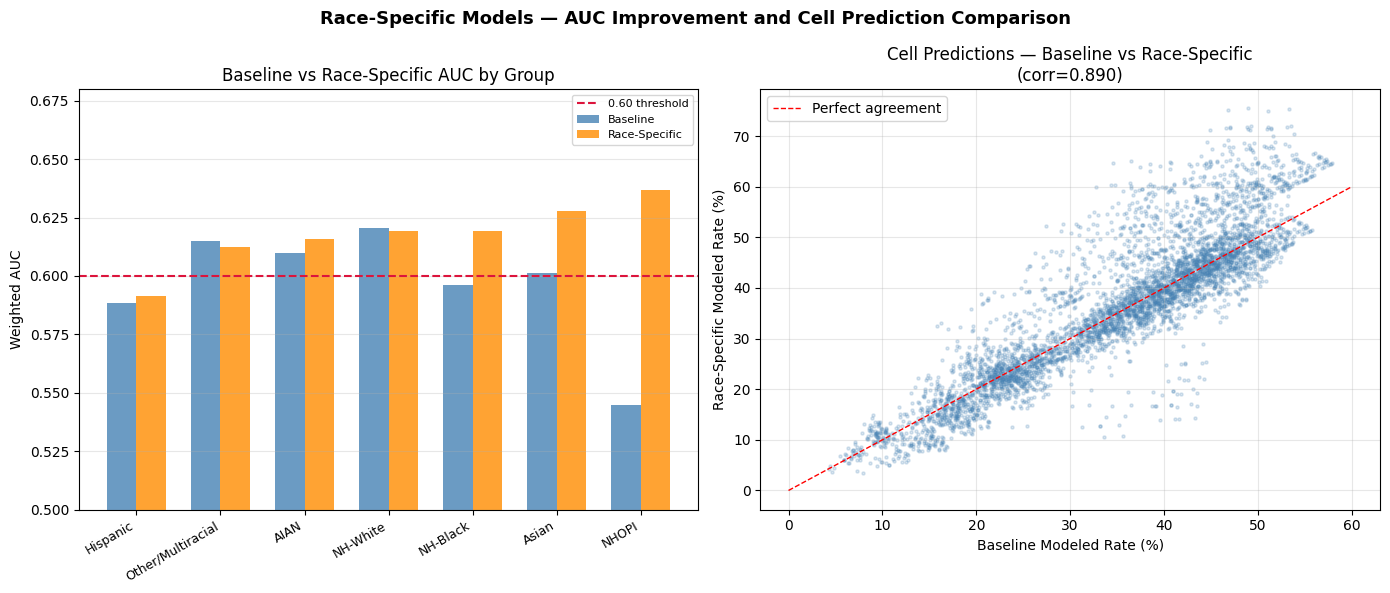

saved brfss_race_specific_model_plots.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Race-Specific Models — AUC Improvement and Cell Prediction Comparison",
             fontsize=13, fontweight="bold")

# Plot 1 — AUC comparison
ax = axes[0]
x = np.arange(len(results_df))
width = 0.35
bars1 = ax.bar(x - width/2, results_df["baseline_auc"], width,
               label="Baseline", color="steelblue", alpha=0.8)
bars2 = ax.bar(x + width/2, results_df["race_specific_auc"], width,
               label="Race-Specific", color="darkorange", alpha=0.8)
ax.axhline(0.60, color="crimson", linestyle="--", linewidth=1.5,
           label="0.60 threshold")
ax.set_xticks(x)
ax.set_xticklabels(results_df["race_group"], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Weighted AUC")
ax.set_title("Baseline vs Race-Specific AUC by Group")
ax.legend(fontsize=8)
ax.set_ylim(0.50, 0.68)
ax.grid(axis="y", alpha=0.3)

# Plot 2 — Cell prediction scatter
ax = axes[1]
ax.scatter(df_summary["obesity_rate_modeled"] * 100,
           df_summary["obesity_rate_race_model"] * 100,
           alpha=0.2, s=5, color="steelblue")
ax.plot([0, 60], [0, 60], "r--", linewidth=1, label="Perfect agreement")
corr = df_summary["obesity_rate_modeled"].corr(df_summary["obesity_rate_race_model"])
ax.set_xlabel("Baseline Modeled Rate (%)")
ax.set_ylabel("Race-Specific Modeled Rate (%)")
ax.set_title(f"Cell Predictions — Baseline vs Race-Specific\n(corr={corr:.3f})")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("brfss_race_specific_model_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved brfss_race_specific_model_plots.png")

## Race-Specific Models

### Motivation
The baseline logistic regression trained on all racial groups simultaneously
produced AUC below 0.60 for three groups — NHOPI (0.545), Hispanic (0.588),
and NH-Black (0.596). A single model trained on 1.32M records is dominated
by NH-White signal (75% of observations) and cannot learn group-specific
demographic patterns effectively.

Race-specific models train a separate logistic regression for each racial
group using only that group's respondents, allowing the model to learn
income, age, and education gradients specific to each community.

### Model Details
- Same features as baseline: age, sex, education, income, state fixed effects
- No race dummy needed — each model is trained on one group only
- Same `_LLCPWT_adjusted` survey weights
- 80/20 train/test split stratified by obesity outcome

### Results

| Race Group | n | Baseline AUC | Race-Specific AUC | Change |
|------------|---|-------------|-------------------|--------|
| NHOPI | 6,646 | 0.5448 | 0.6369 | +0.0921 ⬆️ |
| Asian | 35,418 | 0.6013 | 0.6277 | +0.0264 ⬆️ |
| NH-Black | 100,433 | 0.5963 | 0.6193 | +0.0230 ⬆️ |
| AIAN | 21,173 | 0.6100 | 0.6157 | +0.0057 ⬆️ |
| Hispanic | 121,793 | 0.5883 | 0.5913 | +0.0030 ➡️ |
| NH-White | 997,964 | 0.6204 | 0.6191 | -0.0013 ➡️ |
| Other/Multiracial | 38,813 | 0.6150 | 0.6126 | -0.0024 ➡️ |

### Key Findings

**Race-specific models dramatically improved NHOPI (+0.092).**
The baseline model had insufficient signal for NHOPI within the combined
model. A dedicated model trained on all 6,646 NHOPI respondents learns
demographic patterns specific to this community and crosses the 0.60
threshold comfortably.

**Asian and NH-Black improved meaningfully.**
Both groups benefit from learning group-specific demographic relationships
— the age trajectory and income gradient for these groups differ from
the NH-White dominated baseline.

**Hispanic remains below 0.60 (0.591) — a structural data limitation.**
Despite 121,793 Hispanic respondents and a dedicated model, demographics
alone cannot explain within-group obesity variation for Hispanic populations.
Cultural, geographic, and community factors not captured in BRFSS
demographics drive within-group variation. Suppression protocol recommended
for counties where Hispanic population exceeds 50%.

**Cell predictions highly correlated (r=0.890) with baseline.**
Race-specific models produce similar but slightly higher obesity rate
predictions on average (mean 0.363 vs 0.350). The higher std dev
(0.141 vs 0.117) indicates more meaningful variation across cells.

### Output File
`brfss_group_summary_race_models.csv` — adds `obesity_rate_race_model`
column to the existing group summary. All previous columns retained.
Race-specific modeled rates are available as an alternative to
`obesity_rate_modeled` for post-stratification, particularly for
NHOPI, Asian, and NH-Black cells where AUC improvements are largest.

### Suppression Recommendation
Counties where Hispanic population collectively exceeds 50% should have
obesity estimates flagged as unreliable — demographics do not adequately
predict within-group obesity variation for this population regardless
of modeling approach.